In [3]:
import os

path = "/content/drive/MyDrive/classification_dataset"
for subdir in ["criminal_dataset", "side_profile"]:
    full_path = os.path.join(path, subdir)
    files = os.listdir(full_path)
    print(f"{subdir} has {len(files)} files.")


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/classification_dataset/criminal_dataset'

In [4]:
!ls "/content/drive/MyDrive/classification_dataset"


ls: cannot access '/content/drive/MyDrive/classification_dataset': No such file or directory


In [5]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
!ls "/content/drive/MyDrive"


 Blurred_Images		  face_classification_model.h5	 Sharpened_Images
'Chapter 1.gslides'	  processed_blur		 test.jpeg
 classification_dataset   processed_edge
'Colab Notebooks'	  processed_images


In [7]:
!ls "/content/drive/MyDrive/classification_dataset"


criminal_dataset  side_profile


In [9]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report

# Dataset Path
DATASET_PATH = "/content/drive/MyDrive/classification_dataset"
REQUIRED_CLASSES = ["criminal_dataset", "side_profile"]

# Image Parameters
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Image Generators
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=REQUIRED_CLASSES,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=REQUIRED_CLASSES,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Model Definition
model = Sequential([
    Input(shape=(128, 128, 3)),
    Conv2D(32, (3,3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.3),

    Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

# Compile Model
optimizer = tf.keras.optimizers.Adam()
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train Model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop, lr_schedule]
)

# Evaluation & Report
val_generator.reset()
preds = model.predict(val_generator)
y_pred = np.argmax(preds, axis=1)
y_true = val_generator.classes

report = classification_report(y_true, y_pred, target_names=REQUIRED_CLASSES)
print("Classification Report:\n")
print(report)


Found 3332 images belonging to 2 classes.
Found 831 images belonging to 2 classes.
Epoch 1/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 667s 6s/step - accuracy: 0.7890 - loss: 6.5480 - val_accuracy: 0.9290 - val_loss: 0.8244 - learning_rate: 0.0010
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.9453 - loss: 0.7123 - val_accuracy: 0.8845 - val_loss: 1.8386 - learning_rate: 0.0010
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.9569 - loss: 0.5662 - val_accuracy: 0.9483 - val_loss: 1.0692 - learning_rate: 0.0010
Epoch 4/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.9602 - loss: 0.5136 - val_accuracy: 0.9434 - val_loss: 1.0410 - learning_rate: 0.0010
Epoch 5/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.9797 - loss: 0.4523 - val_accuracy: 0.9495 - val_loss: 1.0944 - learning_rate: 5.0000e-04
Epoch 6/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.9882 - loss: 0.4106 - val_accuracy: 0.9699 - val_loss: 0.6131 - learning_rate: 5.

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, TimeDistributed, LSTM, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# --- Settings ---
SEQUENCE_LENGTH = 5  # Assume 5 frames per sample (or same image repeated for now)
IMG_HEIGHT, IMG_WIDTH = 128, 128
BATCH_SIZE = 16
DATASET_PATH = "/content/drive/MyDrive/classification_dataset"
REQUIRED_CLASSES = ["criminal_dataset", "side_profile"]

# --- Data Preparation (simulate sequence for now) ---
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    classes=REQUIRED_CLASSES,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    classes=REQUIRED_CLASSES,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

# Function to convert batches into sequences (simulate sequence)
def create_sequence(generator, steps, sequence_length):
    x_seq = []
    y_seq = []
    for _ in range(steps):
        x_batch, y_batch = next(generator)
        # Repeat same image across sequence_length for now
        x_seq.append(np.repeat(x_batch[:, np.newaxis, :, :, :], sequence_length, axis=1))
        y_seq.append(y_batch)
    return np.vstack(x_seq), np.vstack(y_seq)

# --- Create training and validation sequences ---
train_x, train_y = create_sequence(train_generator, steps=100, sequence_length=SEQUENCE_LENGTH)
val_x, val_y = create_sequence(val_generator, steps=25, sequence_length=SEQUENCE_LENGTH)

# --- Model Definition: CNN + RNN ---
input_layer = Input(shape=(SEQUENCE_LENGTH, IMG_HEIGHT, IMG_WIDTH, 3))

x = TimeDistributed(Conv2D(32, (3, 3), activation='relu'))(input_layer)
x = TimeDistributed(MaxPooling2D(2))(x)
x = TimeDistributed(Conv2D(64, (3, 3), activation='relu'))(x)
x = TimeDistributed(MaxPooling2D(2))(x)
x = TimeDistributed(Flatten())(x)


Found 3332 images belonging to 2 classes.
Found 831 images belonging to 2 classes.


Found 3332 images belonging to 2 classes.
Found 831 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 216s 2s/step - accuracy: 0.8285 - loss: 1.4805 - val_accuracy: 0.4850 - val_loss: 12.0464
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.9392 - loss: 0.2936 - val_accuracy: 0.4850 - val_loss: 17.6451
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.9747 - loss: 0.2007 - val_accuracy: 0.7906 - val_loss: 2.1365
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 274s 2s/step - accuracy: 0.9704 - loss: 0.2471 - val_accuracy: 0.8797 - val_loss: 0.5620
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step - accuracy: 0.9755 - loss: 0.1969 - val_accuracy: 0.8977 - val_loss: 0.5841
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.9761 - loss: 0.1829 - val_accuracy: 0.9519 - val_loss: 0.2505
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 266s 2s/step - accuracy: 0.9801 - loss: 0.1660 - val_accuracy: 0.9422 - val_loss: 0.3221
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.9833 - loss: 0.1583 - val_ac

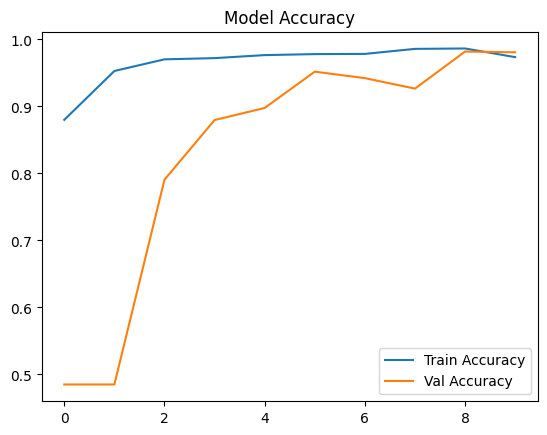

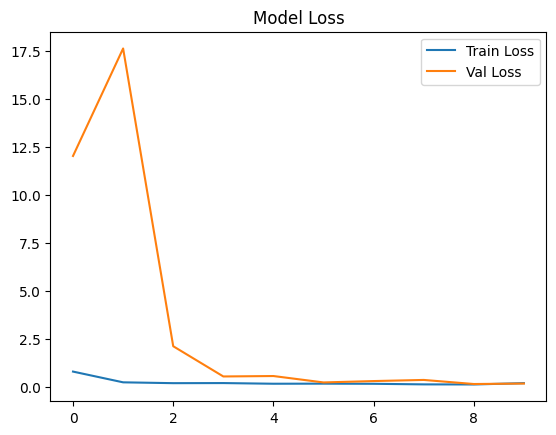

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l2

# Dataset Path
DATASET_PATH = "/content/drive/MyDrive/classification_dataset"
REQUIRED_CLASSES = ["criminal_dataset", "side_profile"]

# Image Data Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(128, 128),
    batch_size=32,
    classes=REQUIRED_CLASSES,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(128, 128),
    batch_size=32,
    classes=REQUIRED_CLASSES,
    class_mode='categorical',
    subset='validation'
)

# Model Definition
model = Sequential([
    Input(shape=(128, 128, 3)),
    Conv2D(32, (3,3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')  # 2 classes: criminal_dataset, side_profile
])

# Compile Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train Model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator),
    verbose=1
)

# Save the model
model.save("face_classification_model.h5")

# Plot Accuracy & Loss
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Model Accuracy")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss")
plt.legend()
plt.show()
